# 1. Importación de Librerías y Carga de Datos

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración visual básica para los gráficos
sns.set_theme(style="whitegrid")

# 1. Cargar el dataset
# Define la ruta relativa
file_path = Path('../data/real_state_ecuador_dataset.csv')
df = pd.read_csv(file_path)

# Vistazo inicial
display(df.head())
print(df.info())

,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages
0,Hermoso departamento de arriendo sector iñaquito,500,Pichincha,"Pichincha, Iñaquito, Quito, Ecuador",2,2.0,95.0,1.0
1,Hermosa suite de arriendo sector iñaquito,375,Pichincha,"Pichincha, Quito, Ecuador",1,1.0,65.0,1.0
2,Hermoso departamento de oportunidad de arriend...,650,Pichincha,"Pichincha, Av. República de El Salvador, Quito...",2,2.0,120.0,1.0
3,Hermoso departamento de arriendo de 240 metros...,560,Pichincha,"Pichincha, Albert Einstein, Quito, Ecuador",3,3.0,240.0,2.0
4,Hermoso departamento de arriendo de oportunida...,580,Pichincha,"Pichincha, Urbanización El Condado, Calle C, Q...",3,4.0,128.0,2.0


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Titulo            500 non-null    str    
 1   Precio            500 non-null    int64  
 2   Provincia         500 non-null    str    
 3   Lugar             500 non-null    str    
 4   Num. dormitorios  360 non-null    str    
 5   Num. banos        403 non-null    float64
 6   Area              482 non-null    float64
 7   Num. garages      348 non-null    float64
dtypes: float64(3), int64(1), str(4)
memory usage: 31.4 KB
None


# 2. Limpieza y Normalización

In [4]:
# 1. Renombrar columnas para estandarizar 
df = df.rename(columns={
    'Titulo': 'titulo',
    'Precio': 'precio',
    'Provincia': 'provincia',
    'Lugar': 'lugar',
    'Num. dormitorios': 'num_dormitorios',
    'Num. banos': 'num_banos',
    'Area': 'area',
    'Num. garages': 'num_garages'
})

# 2. Limpieza de 'num_dormitorios' (Extraer solo números para limpiar textos como "1 HABITACIÓN")
# Usamos expresiones regulares para sacar el primer número que encuentre
df['num_dormitorios'] = df['num_dormitorios'].astype(str).str.extract(r'(\d+)').astype(float)

# 3. Normalización de la columna 'lugar'
# Pasamos a minúsculas, quitamos espacios extra y eliminamos tildes/caracteres especiales
df['lugar'] = df['lugar'].astype(str).str.lower().str.strip()
df['lugar'] = df['lugar'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

# 4. Manejo de valores faltantes (Nulos)
print("Valores nulos ANTES de la limpieza:\n", df.isnull().sum())

# Imputamos con la mediana para evitar que valores atípicos (outliers) sesguen los datos
cols_numericas = ['num_dormitorios', 'num_banos', 'area', 'num_garages']
for col in cols_numericas:
    mediana_col = df[col].median()
    df[col] = df[col].fillna(mediana_col)

# Convertimos las habitaciones, baños y garajes a enteros (no puedes tener 1.5 baños en la predicción final)
cols_enteras = ['num_dormitorios', 'num_banos', 'num_garages']
for col in cols_enteras:
    df[col] = df[col].astype(int)

print("\nValores nulos DESPUÉS de la limpieza:\n", df.isnull().sum())
display(df.head())

Valores nulos ANTES de la limpieza:
 titulo               0
precio               0
provincia            0
lugar                0
num_dormitorios    140
num_banos           97
area                18
num_garages        152
dtype: int64

Valores nulos DESPUÉS de la limpieza:
 titulo             0
precio             0
provincia          0
lugar              0
num_dormitorios    0
num_banos          0
area               0
num_garages        0
dtype: int64


,titulo,precio,provincia,lugar,num_dormitorios,num_banos,area,num_garages
0,Hermoso departamento de arriendo sector iñaquito,500,Pichincha,"pichincha, inaquito, quito, ecuador",2,2,95.0,1
1,Hermosa suite de arriendo sector iñaquito,375,Pichincha,"pichincha, quito, ecuador",1,1,65.0,1
2,Hermoso departamento de oportunidad de arriend...,650,Pichincha,"pichincha, av. republica de el salvador, quito...",2,2,120.0,1
3,Hermoso departamento de arriendo de 240 metros...,560,Pichincha,"pichincha, albert einstein, quito, ecuador",3,3,240.0,2
4,Hermoso departamento de arriendo de oportunida...,580,Pichincha,"pichincha, urbanizacion el condado, calle c, q...",3,4,128.0,2


# 3. Análisis Descriptivo y Métricas de Negocio

--- Total de Propiedades por Provincia ---


provincia
Pichincha     443
Guayas         34
Manabí          9
Esmeraldas      4
Los Rios        3
Name: count, dtype: int64


--- Top 10 Lugares con más propiedades ---


lugar
pichincha, ponceano alto, quito, ecuador                                19
pichincha, el bosque, quito, ecuador                                    12
pichincha, sangolqui, sangolqui, ecuador                                12
pichincha, el colibri, avenida general ruminahui, sangolqui, ecuador    10
pichincha, inaquito, quito, ecuador                                      9
pichincha, quito tenis, quito, ecuador                                   9
pichincha, la carolina, quito, ecuador                                   8
pichincha, gonzalez suarez, quito, ecuador                               7
pichincha, pomasqui, quito, ecuador                                      5
pichincha, sangolqui, ecuador                                            5
Name: count, dtype: int64


--- Métricas Generales de Precio ---
Promedio: $833.70
Mediana: $500.00

--- Métricas de Precio por Lugar (Top 5 con más datos) ---


,count,mean,median
lugar,,,
"pichincha, ponceano alto, quito, ecuador",19,421.052632,400.0
"pichincha, el bosque, quito, ecuador",12,625.833333,525.0
"pichincha, sangolqui, sangolqui, ecuador",12,698.333333,682.5
"pichincha, el colibri, avenida general ruminahui, sangolqui, ecuador",10,534.500000,592.5
"pichincha, quito tenis, quito, ecuador",9,856.666667,750.0


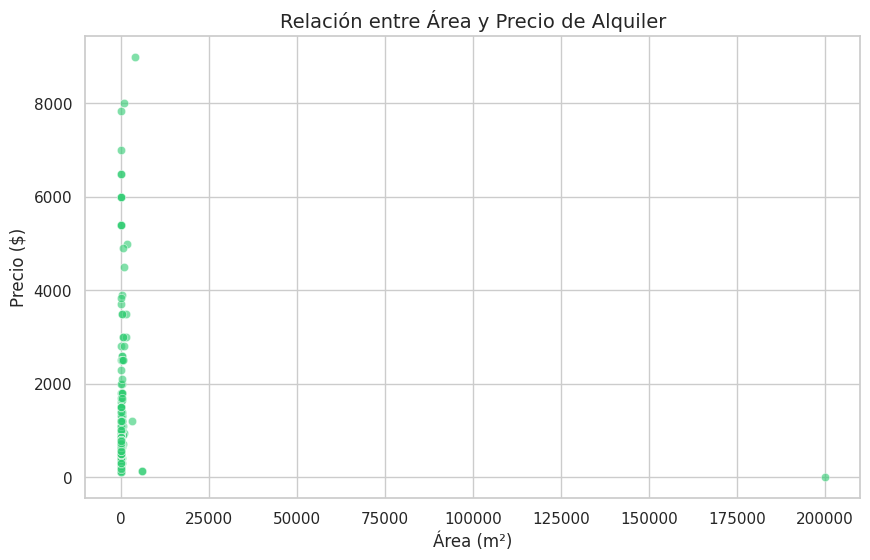


--- Análisis de Premium por Habitación ---


,num_dormitorios,precio_promedio,premium_vs_anterior
0,0,9000.000000,NaN
1,1,849.113924,-8150.886076
2,2,488.443299,-360.670625
3,3,864.197880,375.754581
4,4,1175.000000,310.802120
5,5,1300.000000,125.000000
6,6,1500.000000,200.000000
7,7,3000.000000,1500.000000
8,8,700.000000,-2300.000000
9,10,125.000000,-575.000000



--- Distribución de Tipo de Precio ---


tipo_precio_lugar
Medio        348
Económico     76
Lujo          76
Name: count, dtype: int64


¡Dataset limpio y enriquecido guardado en: ../data/dataset_ecuador_limpio.csv!


In [6]:
# 1. Total de propiedades por Provincia y por Lugar
print("--- Total de Propiedades por Provincia ---")
display(df['provincia'].value_counts().head())

print("\n--- Top 10 Lugares con más propiedades ---")
display(df['lugar'].value_counts().head(10))

# 2. Mediana y promedio de precio (General)
print("\n--- Métricas Generales de Precio ---")
print(f"Promedio: ${df['precio'].mean():.2f}")
print(f"Mediana: ${df['precio'].median():.2f}")

# 3. Mediana y promedio de precio por Lugar
print("\n--- Métricas de Precio por Lugar (Top 5 con más datos) ---")
metricas_lugar = df.groupby('lugar')['precio'].agg(['count', 'mean', 'median']).sort_values(by='count', ascending=False)
display(metricas_lugar.head())

# 4. Relación Área vs Precio
plt.figure(figsize=(10, 6))
# Usamos un scatterplot para ver la dispersión
sns.scatterplot(data=df, x='area', y='precio', alpha=0.6, color='#2ecc71')
plt.title('Relación entre Área y Precio de Alquiler', fontsize=14)
plt.xlabel('Área (m²)', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.show()

# 5. Análisis de Premium por Habitación Adicional
print("\n--- Análisis de Premium por Habitación ---")
# Agrupamos y calculamos el precio promedio por número de dormitorios
premium_df = df.groupby('num_dormitorios')['precio'].mean().reset_index()
# Calculamos la diferencia con la fila anterior (.diff)
premium_df['premium_vs_anterior'] = premium_df['precio'].diff()
premium_df.rename(columns={'precio': 'precio_promedio'}, inplace=True)
display(premium_df)

# 6. Clasificación de Precio por Lugar (Económico, Medio, Lujo)
def clasificar_precio(x):
    # Si hay menos de 2 datos en el grupo, pandas puede devolver NaN en cuartiles, los mandamos a 'Medio'
    if len(x) < 2:
        return np.repeat('Medio', len(x))
        
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    
    condiciones = [x < q1, x > q3]
    resultados = ['Económico', 'Lujo']
    return np.select(condiciones, resultados, default='Medio')

df['tipo_precio_lugar'] = df.groupby('lugar')['precio'].transform(clasificar_precio)

print("\n--- Distribución de Tipo de Precio ---")
display(df['tipo_precio_lugar'].value_counts())

# 7. Guardar el dataset limpio para la Fase de ML
# Usamos la misma ruta relativa que en tu celda 1
ruta_salida = '../data/dataset_ecuador_limpio.csv'
df.to_csv(ruta_salida, index=False)
print(f"\n¡Dataset limpio y enriquecido guardado en: {ruta_salida}!")